# nébuleuses
$\rightarrow$ **calcul du rougissement, de la température et de la densité électronique**

# la cible : m97

et aussi à faire : 
- 20161006_agdra_ngc6543_hd158460_hd145454
- 20240709_10lac_tcrb_vega_alphacep_gamcas_m57_deneb
- 20240710_10lac_chcyg_tcrb_m16_m57_betalyr_vega_alphacep

In [1]:
%matplotlib widget
import numpy as np
from spectro_dashboard import SpectroDashboard

# 1. Afficher le dashboard
db = SpectroDashboard()
db.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling import models, fitting
from specutils import Spectrum
from astropy import units as u

filename = 'data/plouis/_m97_20260224_843.fits'
#filename = '../../../CAPTURES/20260224_m97_merak_procyon/_m97_20260224_843.fits'

# Chargement
sp = Spectrum.read(filename, units=u.adu)

sp = Spectrum(
    spectral_axis=sp.spectral_axis,
    flux=sp.flux.value * u.Unit('adu'),
    meta=sp.meta
)


print('flux unit='+str(sp.flux.unit))
print('lambda unit='+str(sp.spectral_axis.unit))
sp.meta

flux unit=adu
lambda unit=Angstrom


{'header': SIMPLE  =                    T / conforms to FITS standard                      
 BITPIX  =                  -32 / array data type                                
 NAXIS   =                    1 / number of array dimensions                     
 NAXIS1  =                 5284                                                  
 CRVAL1  =    4249.718518405812                                                  
 CDELT1  =   0.5769098322180071                                                  
 EXPTIME =               4200.0                                                  
 OBJNAME = 'm97     '                                                            
 OBJECT  = 'm97     '                                                            
 EXPTIME2= '7 x 600 s'                                                           
 BSS_ITRP=                  451                                                  
 SPE_RPOW=                  451                                                  
 BSS_V

In [3]:
db.show_spectrum(sp.spectral_axis, sp.flux, label=sp.meta['header']['OBJECT'])

--> Spectre 'm97' affiché : 5284 pts, X:[4249.7:7297.5]


In [4]:
from specutils.fitting import fit_generic_continuum
from astropy.modeling import models

continuum_model = models.Polynomial1D(degree=2)
fitted_continuum = fit_generic_continuum(sp, model=continuum_model)

# Normalise le spectre
flux_norm = sp.flux / fitted_continuum(sp.spectral_axis)

# Crée un nouveau Spectrum1D normalisé
spec_norm = Spectrum(spectral_axis=sp.spectral_axis, flux=flux_norm, meta=sp.meta)

db.clear_spectra()
db.show_spectrum(spec_norm.spectral_axis, spec_norm.flux, label=spec_norm.meta['header']['OBJECT'] + ' sans cont')


--> Spectre 'm97 sans cont' affiché : 5284 pts, X:[4249.7:7297.5]


Flux H-alpha fitted: 86.40


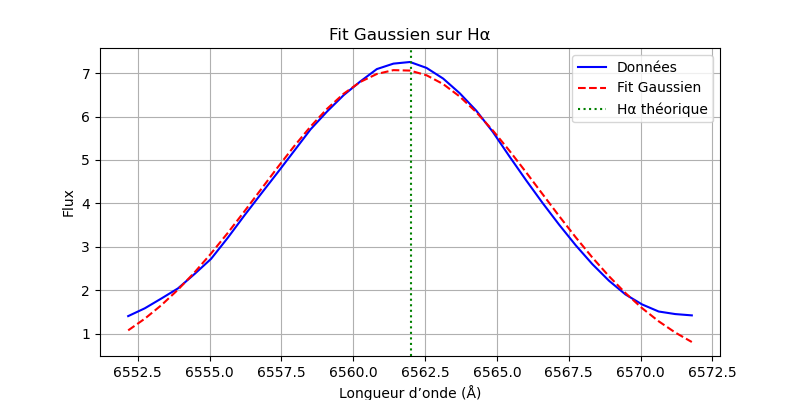

Flux H-beta fitted: 28.75


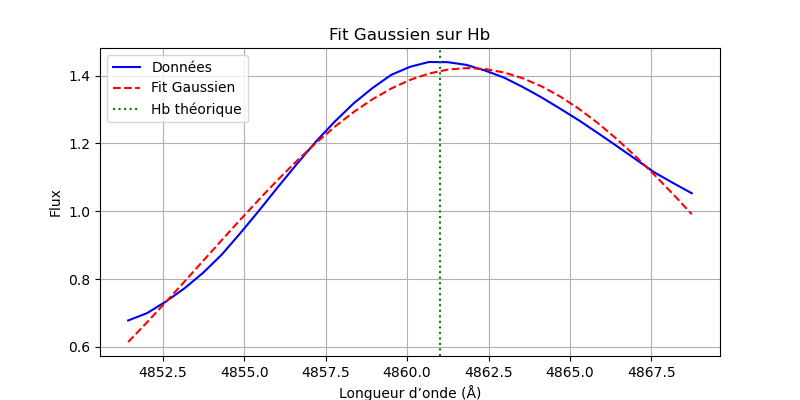

Rapport des flux Ha/Hb fitted : 3.0049786533949385


In [5]:
from specutils.analysis import line_flux
from specutils import SpectralRegion
from specutils.manipulation import extract_region
from astropy import units as u
from scipy.integrate import trapezoid

h_alpha = 6562 * u.AA
h_beta = 4861 * u.AA

reg_ha = SpectralRegion(h_alpha - 10* u.AA, h_alpha + 10 * u.AA)
sub_ha = extract_region(spec_norm, reg_ha) 

#flux_h_alpha = line_flux(spec_norm, reg_ha)
#print(f"Flux H-alpha : {flux_h_alpha:.2f}")

fitter = fitting.LevMarLSQFitter()
gauss_ha = models.Gaussian1D(amplitude=7, mean=h_alpha, stddev=0.8) #+ models.Const1D(amplitude=1.0))

fitted_ha = fitter(gauss_ha,sub_ha.spectral_axis, sub_ha.flux)
#flux_ha_fit = fitted_ha[0].amplitude.value * fitted_ha[0].stddev.value * np.sqrt(2 * np.pi)
flux_ha_fit = fitted_ha.amplitude.value * fitted_ha.stddev.value * np.sqrt(2 * np.pi)
#print(f"Amplitude : {fitted_ha.amplitude.value:.2f}")
#print(f"Mean      : {fitted_ha.mean.value:.2f} Å")
#print(f"Stddev    : {fitted_ha.stddev.value:.2f} Å")
print(f"Flux H-alpha fitted: {flux_ha_fit:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(sub_ha.spectral_axis, sub_ha.flux, 'b-', label='Données')
plt.plot(sub_ha.spectral_axis, fitted_ha(sub_ha.spectral_axis), 'r--', label='Fit Gaussien')
plt.axvline(h_alpha.value, color='green', linestyle=':', label='Hα théorique')
plt.legend()
plt.xlabel('Longueur d’onde (Å)')
plt.ylabel('Flux')
plt.title('Fit Gaussien sur Hα')
plt.grid(True)
plt.show()


reg_hb= SpectralRegion(h_beta - 10 * u.AA, h_beta + 8 * u.AA)
sub_hb = extract_region(spec_norm, reg_hb) 
#flux_h_beta = line_flux(spec_norm, reg_hb)
#print(f"Flux H-beta : {flux_h_beta:.2f}")

fitter = fitting.LevMarLSQFitter()
base_level = np.median(sub_hb.flux.value)
peak_val = np.max(sub_hb.flux.value) - base_level

gauss_hb = models.Gaussian1D(amplitude=1.4, mean=h_beta, stddev=1.5)# + models.Const1D(amplitude=0.8)
           #models.Polynomial1D(degree=1, c0=0, c1=0.0) # c0 = intercept, c1 = pente 

fitted_hb = fitter(gauss_hb, sub_hb.spectral_axis, sub_hb.flux)

# 3. Extraction propre
# fitted_model[0] est la Gaussienne, fitted_model[1] est la constante
#flux_hb_clean = fitted_model[0].amplitude.value * fitted_model[0].stddev.value * np.sqrt(2 * np.pi)

#fitter = fitting.LevMarLSQFitter()
#gauss_hb = (models.Gaussian1D(amplitude=1.4, mean=h_beta, stddev=1.0) + models.Const1D(amplitude=1.0))
#fitted_hb = fitter(gauss_hb,sub_hb.spectral_axis, sub_hb.flux)
#flux_hb_fit = fitted_hb[0].amplitude.value * fitted_hb[0].stddev.value * np.sqrt(2 * np.pi)
flux_hb_fit = fitted_hb.amplitude.value * fitted_hb.stddev.value * np.sqrt(2 * np.pi)

#print(f"Amplitude : {fitted_hb.amplitude.value:.2f}")
#print(f"Mean      : {fitted_hb.mean.value:.2f} Å")
#print(f"Stddev    : {fitted_hb.stddev.value:.2f} Å")
print(f"Flux H-beta fitted: {flux_hb_fit:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(sub_hb.spectral_axis, sub_hb.flux, 'b-', label='Données')
plt.plot(sub_hb.spectral_axis, fitted_hb(sub_hb.spectral_axis), 'r--', label='Fit Gaussien')
plt.axvline(h_beta.value, color='green', linestyle=':', label='Hb théorique')
plt.legend()
plt.xlabel('Longueur d’onde (Å)')
plt.ylabel('Flux')
plt.title('Fit Gaussien sur Hb')
plt.grid(True)
plt.show()

#print(f"Rapport des flux Ha/Hb : {flux_h_alpha / flux_h_beta}")
print(f"Rapport des flux Ha/Hb fitted : {flux_ha_fit / flux_hb_fit}")

#peak_hb = np.max(sub_hb.flux.value)
#peak_ha = np.max(sub_ha.flux.value)

#rapport_sommets = peak_ha / peak_hb

#print(f"Intensité H-beta : {peak_hb:.2f}")
#print(f"Intensité H-alpha : {peak_ha:.2f}")
#print(f"Rapport des sommets Ha/Hb : {peak_ha / peak_hb}")


- Avec ce rapport, on peut calculer l'extinction (logarithmique).
- La poussière "rougit" le spectre en absorbant davantage le bleu ($H\beta$) que le rouge ($H\alpha$).
- La formule standard est :$$c(H\beta) = \frac{1}{K_{H\alpha} - K_{H\beta}} \cdot \log_{10} \left( \frac{R_{mesuré}}{R_{théorique}} \right)$$



In [6]:
def calculer_extinction(ha_flux, hb_flux, r_theo=2.85):
    """
    Calcule le coefficient d'extinction c(Hb) 
    Basé sur le décrément de Balmer Ha/Hb.
    """
    # 1. Calcul du rapport observé
    r_obs = ha_flux / hb_flux
    
    # 2. Paramètres de la loi de Cardelli (CCM 89)
    # f(lambda) pour Ha (6563A) relatif à Hb (4861A)
    # Selon la loi standard, l'écart de pente (f_Ha - f_Hb) est d'environ -0.334
    delta_f = -0.334 
    
    # 3. Formule de calcul de c(Hb)
    # c(Hb) = log10(R_obs / R_theo) / [f(Hb) - f(Ha)]
    # Note : f(Hb) est par définition 0, donc le dénominateur est -delta_f
    c_hb = np.log10(r_obs / r_theo) / (0 - delta_f)
    
    return c_hb, r_obs

c_val, rapport = calculer_extinction(flux_ha_fit, flux_hb_fit)

print(f"Rapport mesuré Ha/Hb : {rapport:.3f}")
print(f"Coefficient d'extinction c(Hb) : {c_val:.3f}")

# --- Calcul du rougissement E(B-V) ---
# Rapport constant : c(Hb) = 1.45 * E(B-V) environ
e_bv = c_val / 1.45
print(f"Rougissement E(B-V) : {e_bv:.3f} mag")



Rapport mesuré Ha/Hb : 3.005
Coefficient d'extinction c(Hb) : 0.069
Rougissement E(B-V) : 0.047 mag
